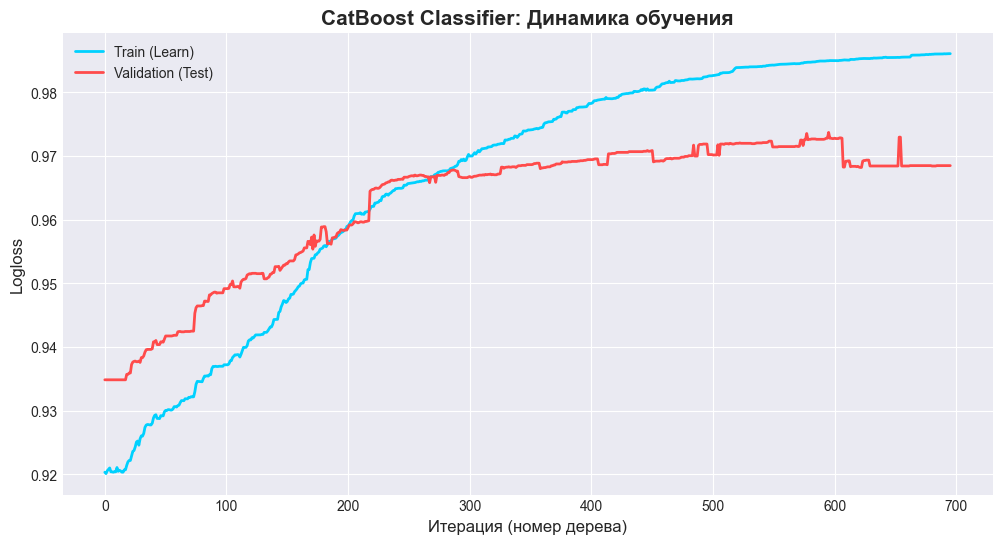

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Загружаем данные из папки catboost_info
# Убедись, что путь правильный (относительно твоего ноутбука)
train_error = pd.read_csv('catboost_info/learn_error.tsv', sep='\t')
test_error = pd.read_csv('catboost_info/test_error.tsv', sep='\t')

# 2. Настраиваем стиль
plt.style.use('seaborn-v0_8-darkgrid') 
plt.figure(figsize=(12, 6))

# Рисуем линии
plt.plot(train_error['iter'], train_error.iloc[:, 1], label='Train (Learn)', color='#00d1ff', linewidth=2)
plt.plot(test_error['iter'], test_error.iloc[:, 1], label='Validation (Test)', color='#ff4b4b', linewidth=2)

# Оформление
plt.title('CatBoost Classifier: Динамика обучения', fontsize=15, fontweight='bold')
plt.xlabel('Итерация (номер дерева)', fontsize=12)
plt.ylabel('Logloss', fontsize=12)
plt.legend()
plt.show()

✅ CatBoost загружен: ../gym_model/catboost_recommender_final.cbm


/var/folders/8s/mgfxfqyn23qftsm7b6_dqkjh0000gn/T/ipykernel_3286/1222369259.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df, palette='magma')


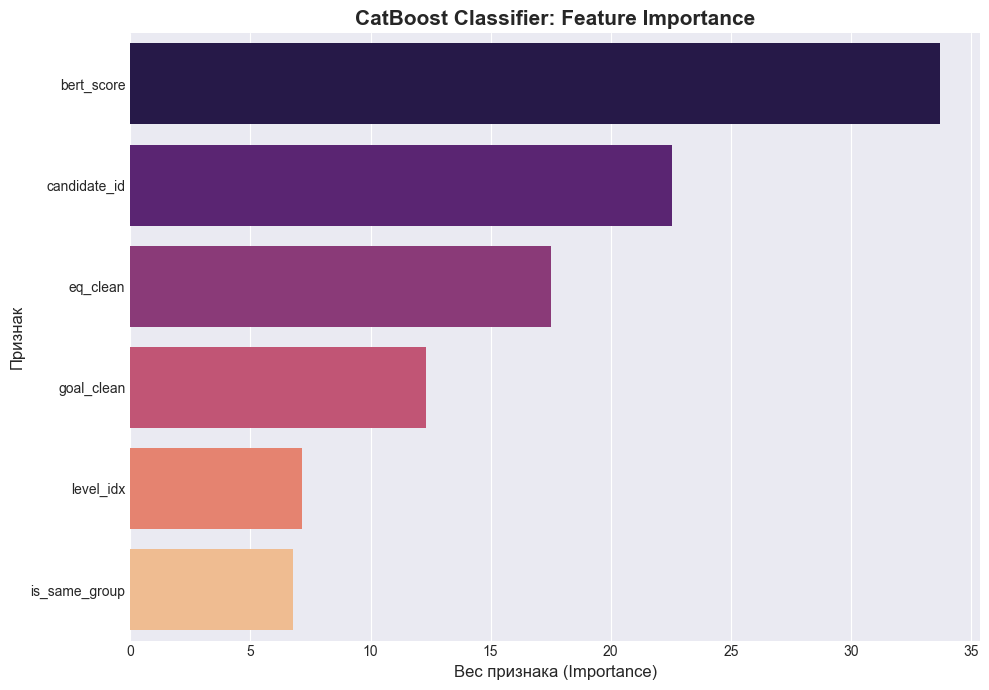

In [11]:
from catboost import CatBoostClassifier
import os

data_folder = "../gym_model"
cat_ranker = CatBoostClassifier()
cat_path = "catboost_recommender_final.cbm"
if not os.path.exists(cat_path):
    cat_path = f'{data_folder}/{cat_path}'

if os.path.exists(cat_path):
    cat_ranker.load_model(cat_path)
    print(f"✅ CatBoost загружен: {cat_path}")
    
# Извлекаем важность признаков из твоей модели cat_ranker
feature_importance = cat_ranker.get_feature_importance()
feature_names = ['bert_score', 'candidate_id', 'is_same_group', 'eq_clean', 'level_idx', 'goal_clean']

# Создаем DataFrame для удобства отрисовки
fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

# Рисуем
plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='magma')

plt.title('CatBoost Classifier: Feature Importance', fontsize=15, fontweight='bold')
plt.xlabel('Вес признака (Importance)', fontsize=12)
plt.ylabel('Признак', fontsize=12)
plt.tight_layout()
plt.show()